In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/HistoricalData_1782120618316.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please check the file path and try again.")
    df = None

if df is not None:
    print("\n--- Initial Data Inspection ---")
    print("Head of the dataset:")
    print(df.head())

    print("\nInformation about the dataset:")
    df.info()

    print("\nDescriptive statistics:")
    print(df.describe())

    print("\nMissing values per column:")
    print(df.isnull().sum())

    # Data Preprocessing
    # Check if 'Date' column exists and convert
    if 'Date' in df.columns:
        try:
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date')
            df.set_index('Date', inplace=True)
            print("\n'Date' column converted to datetime and set as index.")
        except Exception as e:
            print(f"Error converting 'Date' column: {e}")
    else:
        print("Warning: 'Date' column not found. Please check the dataset columns.")

    # Define columns that need cleaning for '$' and conversion to float
    currency_cols = ['Close/Last', 'Open', 'High', 'Low']

    for col in currency_cols:
        if col in df.columns:
            # Remove '$' and commas, then convert to numeric
            df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

    # Volume column is already int64 as per df.info(), so no need to process it for '$'
    # If 'Volume' was an object type, it would be handled here (similar to currency_cols)
    # Example if 'Volume' needed cleaning:
    # if 'Volume' in df.columns:
    #     df['Volume'] = df['Volume'].astype(str).str.replace(',', '', regex=False).astype(float)

    # Handle 'Change %' if it exists
    if 'Change %' in df.columns:
        df['Change %'] = df['Change %'].astype(str).str.replace('%', '', regex=False).astype(float) / 100

    print("\nData types after conversion:")
    df.info()
    print("\nFirst 5 rows after preprocessing:")
    print(df.head())


Successfully loaded data from /content/HistoricalData_1782120618316.csv

--- Initial Data Inspection ---
Head of the dataset:
         Date Close/Last    Volume      Open     High      Low
0  06/18/2026    $400.49  58384710  $398.095  $402.52  $384.70
1  06/17/2026    $396.38  43534300   $401.53  $405.94  $393.76
2  06/16/2026    $404.66  40255470   $404.11  $412.42  $400.54
3  06/15/2026    $411.15  45620510   $412.37  $416.00  $407.10
4  06/12/2026    $406.43  63652290   $399.49  $406.68  $386.76

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        19 non-null     object
 1   Close/Last  19 non-null     object
 2   Volume      19 non-null     int64 
 3   Open        19 non-null     object
 4   High        19 non-null     object
 5   Low         19 non-null     object
dtypes: int64(1), object(5)
memory usage: 


--- Visualizing Stock Price and Volume Trends ---


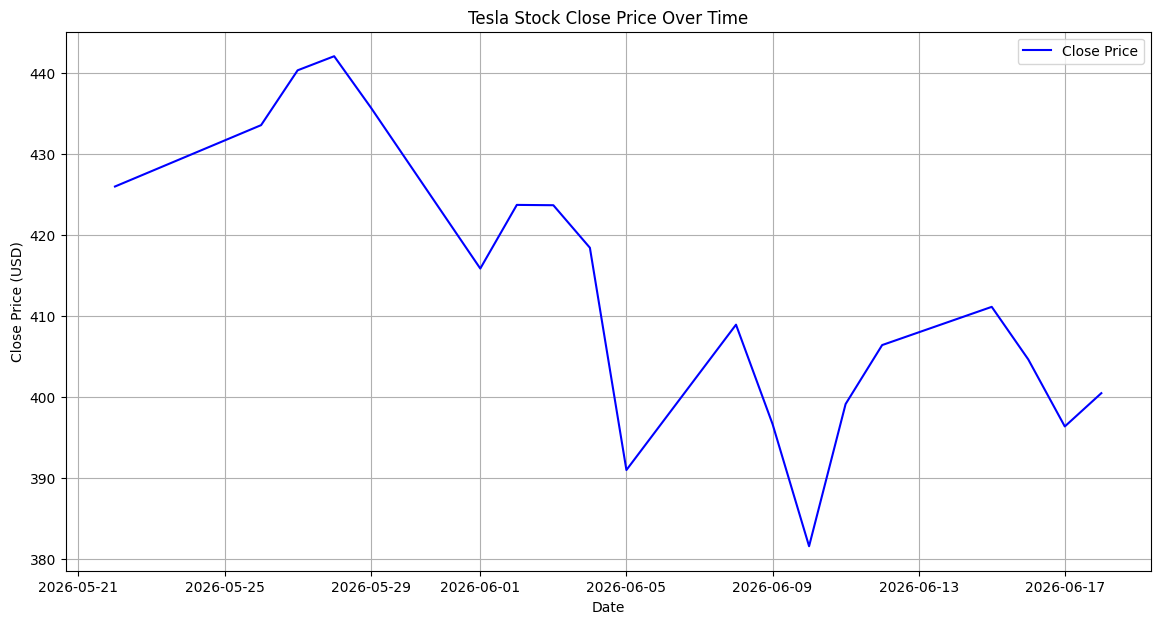

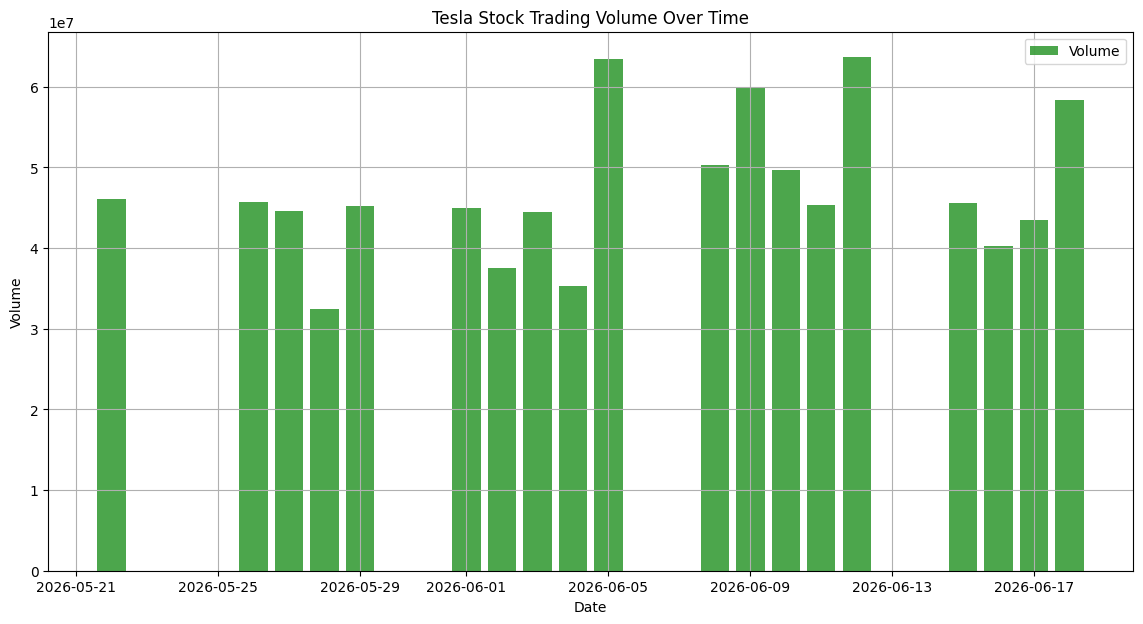


--- Daily Returns Analysis ---


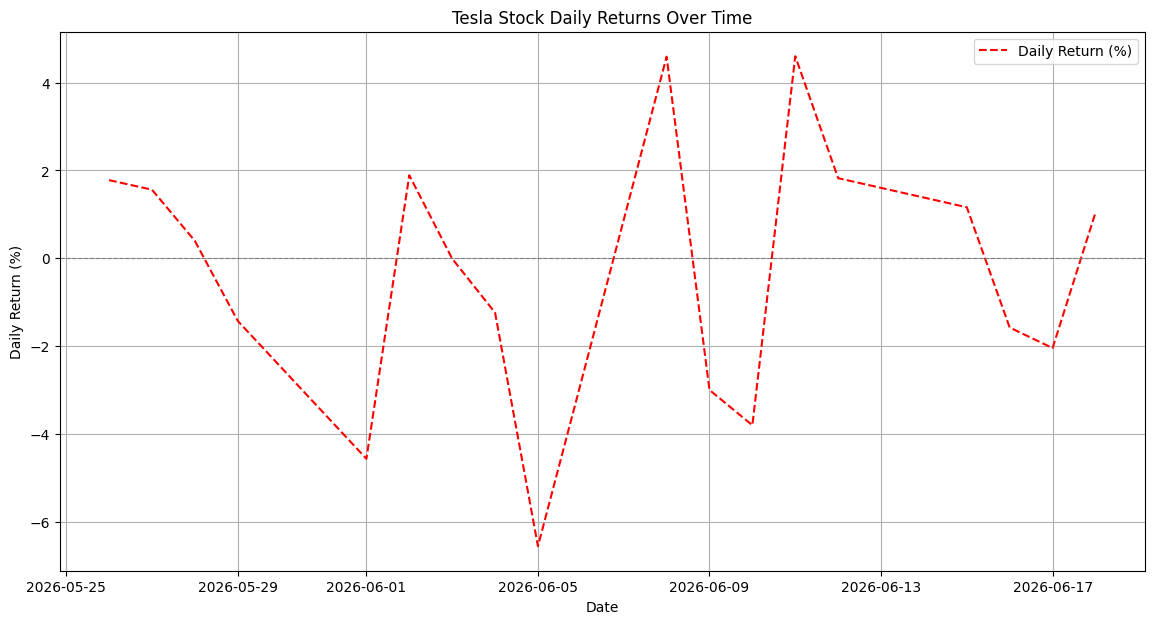

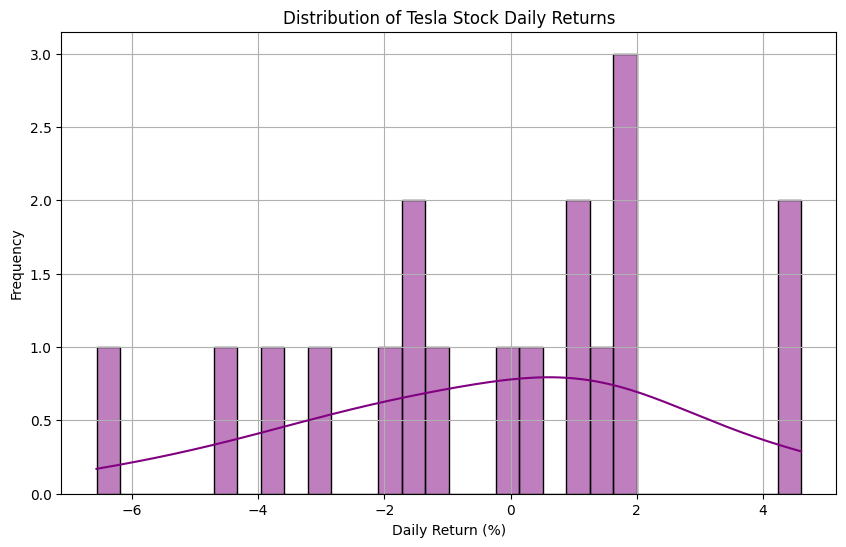


Basic Statistics of Daily Returns:
count    18.000000
mean     -0.299615
std       3.003412
min      -6.559924
25%      -1.929246
50%       0.192846
75%       1.724821
max       4.601798
Name: Daily Return, dtype: float64


In [3]:
print("\n--- Visualizing Stock Price and Volume Trends ---")

# Plotting Close Price over time
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close/Last'], label='Close Price', color='blue')
plt.title('Tesla Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True)
plt.legend()
plt.show()

# Plotting Volume over time
plt.figure(figsize=(14, 7))
plt.bar(df.index, df['Volume'], label='Volume', color='green', alpha=0.7)
plt.title('Tesla Stock Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.legend()
plt.show()

print("\n--- Daily Returns Analysis ---")
# Calculate daily returns
df['Daily Return'] = df['Close/Last'].pct_change() * 100

# Plotting Daily Returns
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Daily Return'], label='Daily Return (%)', color='red', linestyle='--')
plt.title('Tesla Stock Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True)
plt.legend()
plt.show()

# Histogram of Daily Returns to visualize distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Daily Return'].dropna(), bins=30, kde=True, color='purple')
plt.title('Distribution of Tesla Stock Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Basic statistics of Daily Returns
print("\nBasic Statistics of Daily Returns:")
print(df['Daily Return'].describe())


### 1. Moving Averages Analysis

Moving averages are widely used technical indicators to smooth out price data over a specific period, helping to identify trends and potential support/resistance levels. We'll calculate 5-day (short-term) and 20-day (long-term) Simple Moving Averages (SMA).


--- Moving Averages Analysis ---


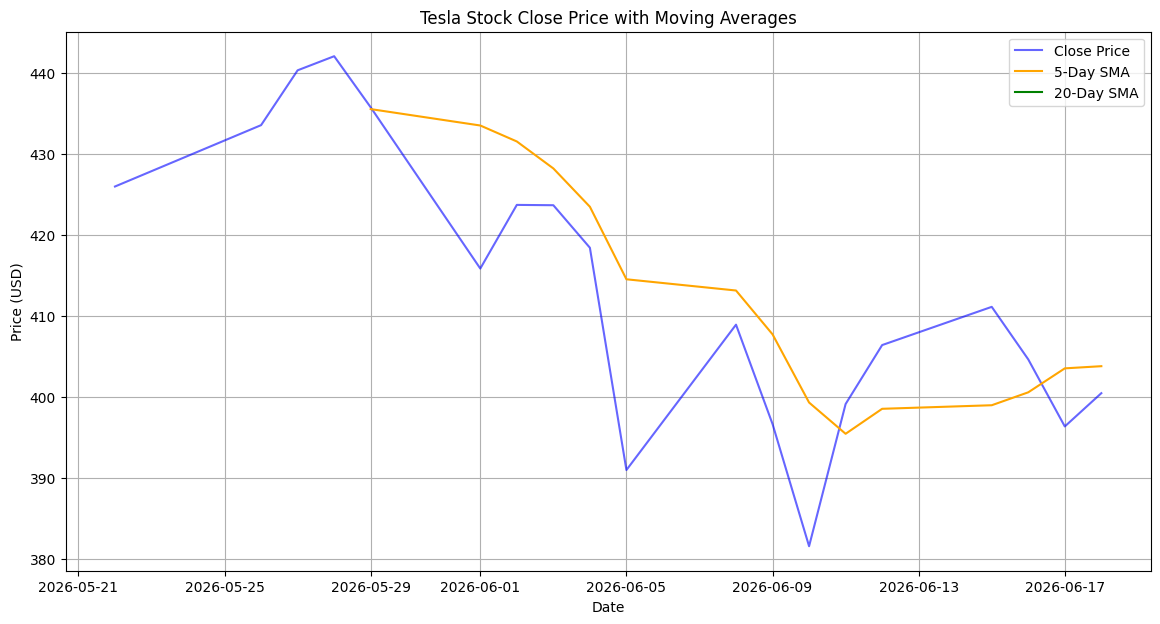

First few rows with Moving Averages:
            Close/Last    SMA_5  SMA_20
Date                                   
2026-05-22      426.01      NaN     NaN
2026-05-26      433.59      NaN     NaN
2026-05-27      440.36      NaN     NaN
2026-05-28      442.10      NaN     NaN
2026-05-29      435.79  435.570     NaN
2026-06-01      415.88  433.544     NaN
2026-06-02      423.74  431.574     NaN
2026-06-03      423.70  428.242     NaN
2026-06-04      418.45  423.512     NaN
2026-06-05      391.00  414.554     NaN


In [4]:
print("\n--- Moving Averages Analysis ---")

# Calculate Simple Moving Averages (SMA)
# Assuming a 5-day (short-term) and 20-day (long-term) moving average
# Note: With only 19 days of data, a 20-day MA will not be fully populated.
# We will use the available data for demonstration purposes.

df['SMA_5'] = df['Close/Last'].rolling(window=5).mean()
df['SMA_20'] = df['Close/Last'].rolling(window=20).mean()

# Plotting Moving Averages
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close/Last'], label='Close Price', color='blue', alpha=0.6)
plt.plot(df.index, df['SMA_5'], label='5-Day SMA', color='orange')
plt.plot(df.index, df['SMA_20'], label='20-Day SMA', color='green')
plt.title('Tesla Stock Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()
plt.show()

print("First few rows with Moving Averages:")
print(df[['Close/Last', 'SMA_5', 'SMA_20']].head(10))

### 2. Volatility Analysis

Volatility measures the degree of variation of a trading price series over time. Higher volatility means the price can change dramatically over a short time period in either direction. We'll look at the rolling standard deviation of daily returns.


--- Volatility Analysis ---


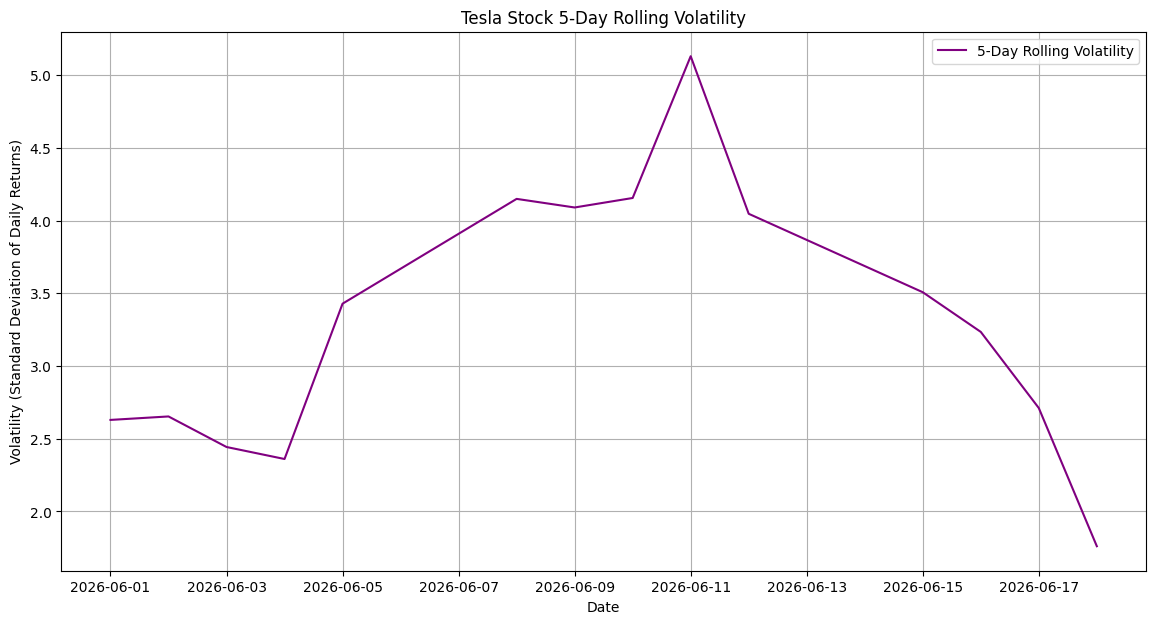

First few rows with Rolling Volatility:
            Daily Return  Rolling Volatility
Date                                        
2026-05-22           NaN                 NaN
2026-05-26      1.779301                 NaN
2026-05-27      1.561383                 NaN
2026-05-28      0.395131                 NaN
2026-05-29     -1.427279                 NaN
2026-06-01     -4.568714            2.629094
2026-06-02      1.889968            2.652933
2026-06-03     -0.009440            2.442862
2026-06-04     -1.239084            2.360267
2026-06-05     -6.559924            3.428444


In [5]:
print("\n--- Volatility Analysis ---")

# Calculate rolling standard deviation of daily returns (e.g., 5-day rolling volatility)
# Note: This will also be limited by the short data period.
window_size = 5 # for rolling volatility
df['Rolling Volatility'] = df['Daily Return'].rolling(window=window_size).std()

# Plotting Rolling Volatility
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Rolling Volatility'], label=f'{window_size}-Day Rolling Volatility', color='purple')
plt.title(f'Tesla Stock {window_size}-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation of Daily Returns)')
plt.grid(True)
plt.legend()
plt.show()

print("First few rows with Rolling Volatility:")
print(df[['Daily Return', 'Rolling Volatility']].head(10))

### 3. Risk Assessment

Risk assessment in stock analysis often involves metrics like annualized volatility. Given the short dataset, we'll calculate the annualized standard deviation of daily returns as a proxy for risk. A higher value indicates higher risk.

In [6]:
print("\n--- Risk Assessment ---")

# Calculate annualized volatility
# Assuming 252 trading days in a year
annualized_volatility = df['Daily Return'].std() * (252**0.5)

print(f"Annualized Volatility of Tesla Stock: {annualized_volatility:.2f}%")
print("Note: This is an estimation and might not be fully accurate due to the limited historical data period (only 19 days). For a more robust analysis, a longer data history is required.")


--- Risk Assessment ---
Annualized Volatility of Tesla Stock: 47.68%
Note: This is an estimation and might not be fully accurate due to the limited historical data period (only 19 days). For a more robust analysis, a longer data history is required.


### 4. Seasonality/Trend Analysis

While 19 days is a very short period to detect meaningful seasonality or long-term trends, we can still perform a rudimentary check, for example, by looking at average daily returns per day of the week. This will be more illustrative of the method rather than providing significant insights for such a limited dataset.


--- Seasonality/Trend Analysis (Limited Data) ---


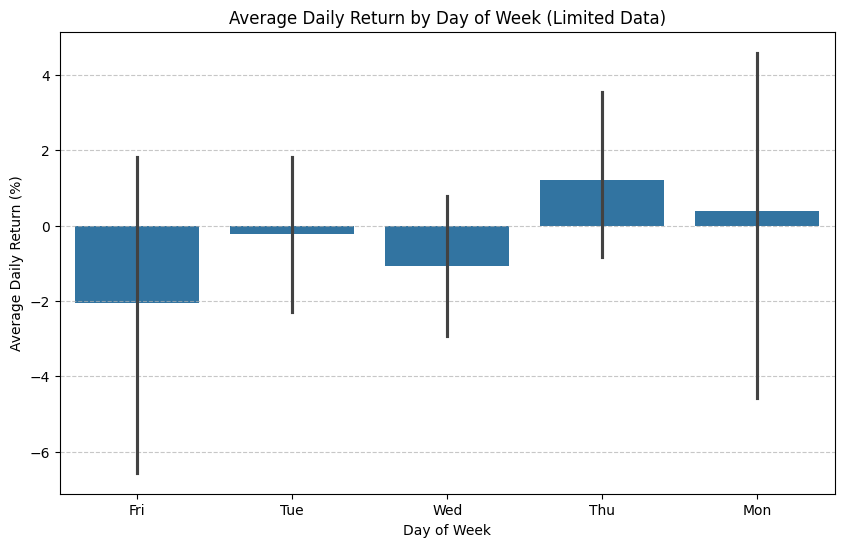

Average Daily Returns by Day of Week:
Day of Week
0    0.394470
1   -0.227399
2   -1.074573
3    1.198682
4   -2.054442
Name: Daily Return, dtype: float64

Due to the very short period (19 days), any observed patterns in seasonality are unlikely to be statistically significant or representative of long-term trends.


In [7]:
print("\n--- Seasonality/Trend Analysis (Limited Data) ---")

# Extract day of the week
df['Day of Week'] = df.index.dayofweek # Monday=0, Sunday=6

# Calculate average daily return per day of the week
plt.figure(figsize=(10, 6))
sns.barplot(x=df['Day of Week'].map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri'}), y=df['Daily Return'])
plt.title('Average Daily Return by Day of Week (Limited Data)')
plt.xlabel('Day of Week')
plt.ylabel('Average Daily Return (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Daily Returns by Day of Week:")
print(df.groupby('Day of Week')['Daily Return'].mean())

print("\nDue to the very short period (19 days), any observed patterns in seasonality are unlikely to be statistically significant or representative of long-term trends.")